# DEF-D Fysieke Ontwerpopdracht 5 Invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 26     |  |
| :-------------|:-------------|
| Matthias Grablowitz| 6247261 |
| Dexter Mourik| 6270433 |
| Teun van Zeeland| 6479510 |

## Opdracht 1: Planning.

| Planning Groep: XX     |Tijdstip / Tijdspanne  | door wie  |
|---|---|---|
| Arduino testen| 11:00 | Dexter |
| ontwerp-eis berekenen| 11:00-11:15 | Matthias & Teun|
| werken met acceleratiemeter | tot 12:30 | hele groep |
| Eerste design af  | 13:45-15:00 | hele groep |
| Volledig af | 16:30 | hele groep | 
| Pauze 1| 12:30-13:45 | hele groep |


Run onderstaande cel om alle benodigde libraries te laden. Mogelijk voeg je er zelf nog een aantal toe later vandaag. 

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
import math

## Opdracht 2a: Opsplitsen taak 1: Arduino
Vul onderstaande tabel in:

| onderwerp    | antwoord  |
|---|---|
| hoe moeilijk (schaal 1 - 10) |  |
| hoe lang voor één meting |  |
| verwacht nauwkeurigheid meting |  |

## Opdracht 2b: Opsplitsen taak 2: afleiding ontwerpeis

$\frac{A_m}{A_v}=\frac{1}{1-\frac{\omega^2}{\omega _0^2}}$. Met .$|\frac{A_m}{A_v}|=1/3$ en $\omega=5*2*\pi$, dus $1-\frac{100\pi^2}{\omega _0^2}=-3$, dit geeft $\omega _0^2=\frac{100\pi^2}{4}$, $\omega _0=5\pi$

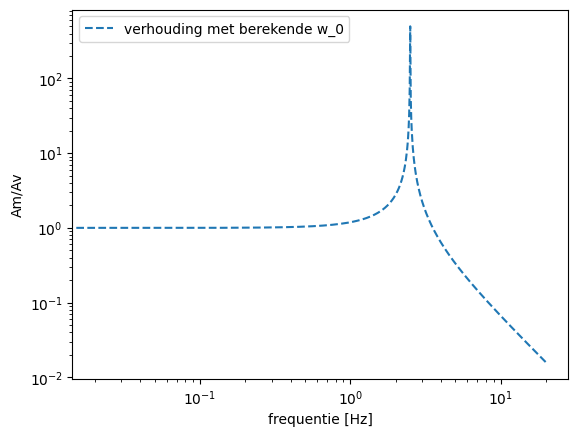

In [2]:
w_0 = 2.5*2*np.pi
g=9.81
def verhouding(f,w_0):

    return 1/(1-4*np.pi**2*f**2/w_0**2)
f_test = np.linspace(0,20,1000)

plt.plot(f_test,np.abs(verhouding(f_test,w_0)),'--',label='verhouding met berekende w_0')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('frequentie [Hz]')
plt.ylabel('Am/Av')
plt.legend()
plt.show()

In [3]:
delta_x_min = g/w_0**2

f0 = w_0 / (2 * np.pi) 
print(delta_x_min, f0)


0.039758432461253344 2.5


## Opdracht 3: Plot de grafiek.

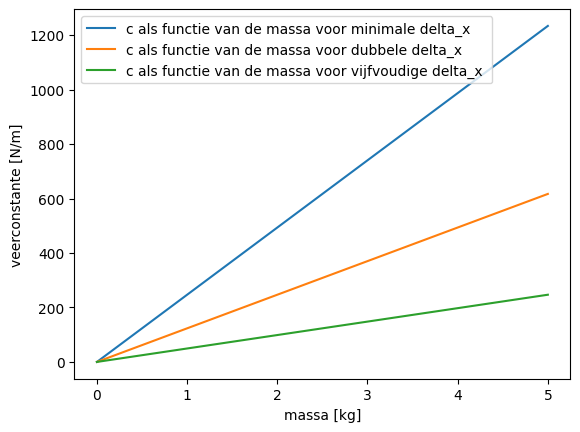

In [4]:
def c(m,delta_x,g):
    return m*g/delta_x
m = np.linspace(0,5,10000)
plt.plot(m,c(m,delta_x_min,g),label = 'c als functie van de massa voor minimale delta_x ')
plt.plot(m,c(m,2*delta_x_min,g,),label = 'c als functie van de massa voor dubbele delta_x ')
plt.plot(m,c(m,5*delta_x_min,g,),label = 'c als functie van de massa voor vijfvoudige delta_x ')
plt.xlabel('massa [kg]')
plt.ylabel('veerconstante [N/m]')
plt.legend()
plt.show()

## Opdracht 4: Verander $\Delta x$.

We kunnen $\Delta x$ verhogen door:

- Een lagere veerconstante te gebruiken
- Een grotere massa te gebruiken

Vul onderstaande aan. Geef eventueel met tekst aan waarom je hiervoor gekozen hebt, als extra informatie richting de nakijkers. 

verwachtte doorsnee:
 2*10**-6 m

Als groep gaan we mikken op een $\Delta x$ van: 0,06 m 

## Opdracht 5: Schets.

##### schets opstelling: 
<img src="schets.jpeg" width="400">

## Opdracht 6: Beslissing evaluatie

Voldoet je ontwerp aan de eisen? Beantwoord de volgende vragen:

### Wat is de $\Delta x$ van je ontwerp?

0.06m

### Wordt die $\Delta x$ behaald met je gekozen massa en veer?

Ja, met 8 elastiekjes en een gewicht van 2.25 kg  

### hoeveel verder kan je massa-veer systeem nog uitrekken / indrukken?
Wat is de limiet aan je veer / verend materiaal voordat het niet meer lineair reageert volgens de wet van Hooke?

Tot 13-14 cm voldoet het elastiekje aan Hooke's law

### Is dat genoeg om straks metingen te kunnen doen?
Hou er rekening mee dat je trillingen een amplitude in de orde grote van een paar centimeter gaan hebben, minder is met deze opzet moeilijk te realiseren.

Ja, dat is een marge van 8 cm

### Gaat je ontwerp dus voldoen aan de eis?

Ja

Als je hier positief geantwoord heb, maak dan nog een keer een plot van amplitude overdracht (y-as) versus frequentie (x-as) zoals je hierboven ook al een keer gedaan heb, maar plot nu twee verschillende overdrachten in de grafiek: één die je al had: behorende bij de grens van de ontwerp-eis en één behorende bij je eigen ontwerp. Lees af dat je voor je ontwerp daadwerkelijk onder de eis grafiek zit op de kritieke frequentie!

Deze grafiek heb je later weer nodig om je gemeten punten aan toe te voegen. Ga daarna je massa-veer systeem daadwerkelijk bouwen.

Als je hier negatief geantwoord hebt, kopieer onder deze cel dan alle cellen van Synthese tot en met Evaluation & decision en doorloop dat deel van het ontwerp proces nogmaals.

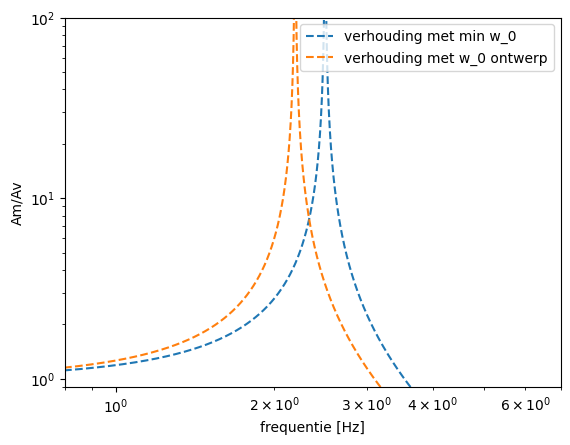

-1.1465048495448673


In [5]:
# Voeg hier je plot in.
w_0 = 5*np.pi
C= 8*46
w_0_2 = 13.776

def verhouding(f,w_0):

    return 1/(1-4*np.pi**2*f**2/w_0**2)
f_test = np.linspace(0,20,10000)

plt.plot(f_test,np.abs(verhouding(f_test,w_0)),'--',label='verhouding met min w_0')
plt.plot(f_test,np.abs(verhouding(f_test,w_0_2)),'--',label='verhouding met w_0 ontwerp')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('frequentie [Hz]')
plt.ylabel('Am/Av')
plt.xlim(0.8,7)
plt.ylim(0.9,100)
plt.legend()
plt.show()
print(verhouding(3,w_0_2))



## Opdracht 7: Plotten maar

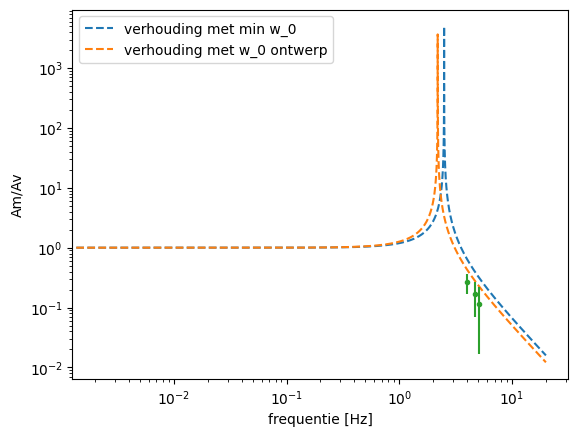

In [6]:
amplitude_ver = np.array([0.38/2.25,0.28/2.4,0.41/1.52])
freq = np.array([4.7,5.1,4.0])
plt.plot(f_test,np.abs(verhouding(f_test,w_0)),'--',label='verhouding met min w_0')
plt.plot(f_test,np.abs(verhouding(f_test,w_0_2)),'--',label='verhouding met w_0 ontwerp')
plt.errorbar(freq,amplitude_ver,0.1,0.1,'.')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('frequentie [Hz]')
plt.ylabel('Am/Av')

plt.legend()
plt.show()

## Opdracht 8: Leerdoelen
Leerdoel: Inzien dat de parameters in een differentiaalvergelijking ontwerpparameters zijn die een
ontwerpruimte opspannen.


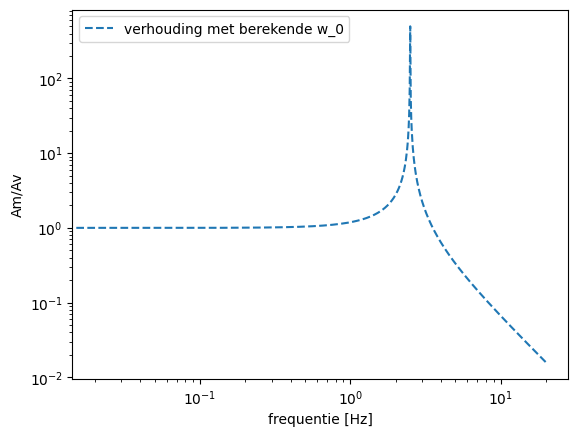

0.039758432461253344 2.5


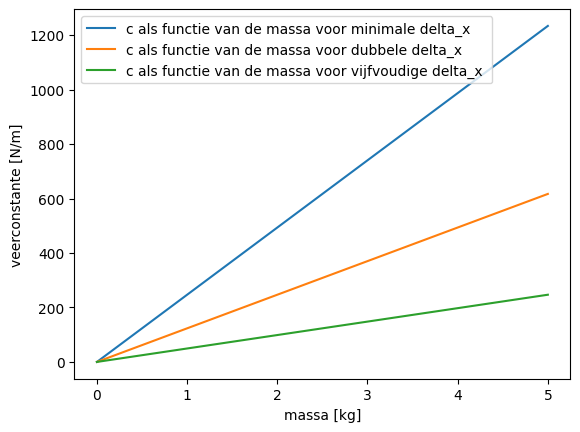

In [7]:

w_0 = 2.5*2*np.pi
g=9.81
def verhouding(f,w_0):

    return 1/(1-4*np.pi**2*f**2/w_0**2)
f_test = np.linspace(0,20,1000)

plt.plot(f_test,np.abs(verhouding(f_test,w_0)),'--',label='verhouding met berekende w_0')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('frequentie [Hz]')
plt.ylabel('Am/Av')
plt.legend()
plt.show()




delta_x_min = g/w_0**2

f0 = w_0 / (2 * np.pi) 
print(delta_x_min, f0)



def c(m,delta_x,g):
    return m*g/delta_x
m = np.linspace(0,5,10000)
plt.plot(m,c(m,delta_x_min,g),label = 'c als functie van de massa voor minimale delta_x ')
plt.plot(m,c(m,2*delta_x_min,g,),label = 'c als functie van de massa voor dubbele delta_x ')
plt.plot(m,c(m,5*delta_x_min,g,),label = 'c als functie van de massa voor vijfvoudige delta_x ')
plt.xlabel('massa [kg]')
plt.ylabel('veerconstante [N/m]')
plt.legend()
plt.show()

### Leerdoel: Op basis van een differentiaal vergelijking een keuze maken voor parameters en die vervolgens kunnen vertalen in een fysiek ontwerp 

Voldoet je ontwerp aan de eisen? Beantwoord de volgende vragen:

### Wat is de $\Delta x$ van je ontwerp?

0.06m

### Wordt die $\Delta x$ behaald met je gekozen massa en veer?

Ja, met 8 elastiekjes en een gewicht van 2.25 kg  

### hoeveel verder kan je massa-veer systeem nog uitrekken / indrukken?
Wat is de limiet aan je veer / verend materiaal voordat het niet meer lineair reageert volgens de wet van Hooke?

Tot 13-14 cm voldoet het elastiekje aan Hooke's law

### Is dat genoeg om straks metingen te kunnen doen?
Hou er rekening mee dat je trillingen een amplitude in de orde grote van een paar centimeter gaan hebben, minder is met deze opzet moeilijk te realiseren.

Ja, dat is een marge van 8 cm

### Gaat je ontwerp dus voldoen aan de eis?

Ja



<img src="schets.jpeg" width="400">
<img src="opstelling.jpeg" width="400">

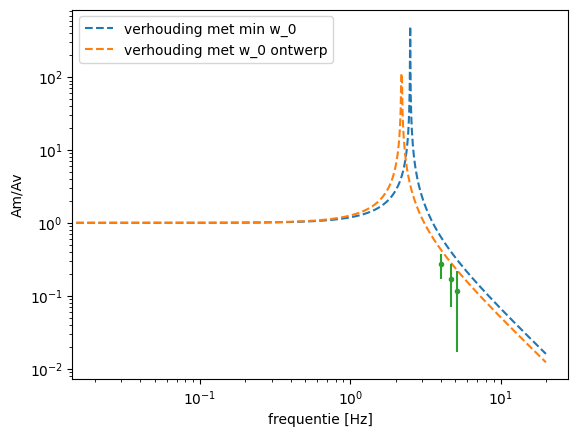

In [8]:
amplitude_ver = np.array([0.38/2.25,0.28/2.4,0.41/1.52])
freq = np.array([4.7,5.1,4.0])
plt.plot(f_test,np.abs(verhouding(f_test,w_0)),'--',label='verhouding met min w_0')
plt.plot(f_test,np.abs(verhouding(f_test,w_0_2)),'--',label='verhouding met w_0 ontwerp')
plt.errorbar(freq,amplitude_ver,0.1,0.1,'.')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('frequentie [Hz]')
plt.ylabel('Am/Av')

plt.legend()
plt.show()

#### Als je je figuren onderweg opgeslagen hebt, kan je ze hier invoegen:
